In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in data, here the top protein and TRN combos with relevant cluster (RFI) IDs
df = pd.read_csv('data/top_protein_pathway_combos_clusterid.csv')

In [3]:
# Create a unique identifier for each protein–cluster pair
df['id'] = df['protein'] + '___' + df['cluster_id']

# Remove duplicate rows based on this identifier
# Keeps only one instance of each protein–cluster pair
df2 = df.drop_duplicates(subset='id')

# Count how many times each protein–cluster pair appears in the original dataframe
# Returns a dataframe where index = id and value = count
df3 = pd.DataFrame(df['id'].value_counts())

# Count how often each frequency occurs (i.e., "counts of counts")
# df3 contains counts per protein–cluster pair, so this tells you:
# how many pairs appear once, twice, three times, etc.
count_of_counts = df3.value_counts().sort_index()

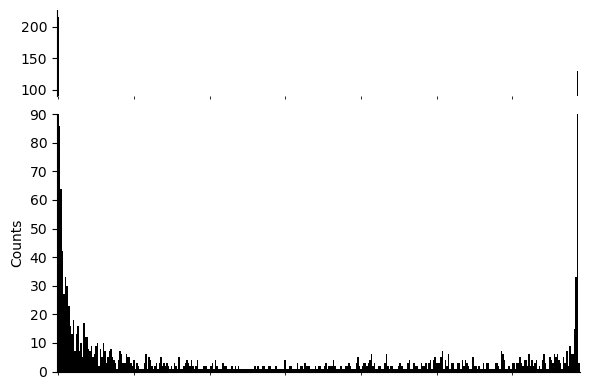

In [4]:
# Create two vertically stacked subplots with a broken y-axis
# Top axis shows high values, bottom axis shows the main distribution
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]},  # top is smaller than bottom
    figsize=(6, 4)
)

# Plot the same bar chart on both axes
# This allows us to visually "split" the y-axis
for ax in (ax_top, ax_bot):
    count_of_counts.plot(
        kind="bar",
        ax=ax,
        width=1.0,
        linewidth=0,
        color="black"
    )

# Set y-axis limits to create the break
# Bottom shows 0–90, top shows only values above 90
ax_top.set_ylim(90, count_of_counts.max() * 1.05)
ax_bot.set_ylim(0, 90)

# Remove x-axis ticks and labels from the bottom for a cleaner look
ax_bot.set_xticks([])
ax_bot.set_xlabel("")

# Set y-axis label
ax_bot.set_ylabel("Counts")

# Remove unnecessary spines and gridlines for a cleaner aesthetic
for ax in (ax_top, ax_bot):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

# Remove the shared boundary spines to emphasize the axis break
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)

# Show plot
plt.tight_layout()
plt.show()